In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [47]:
x = np.arange(20)
y = np.random.rand(len(x))

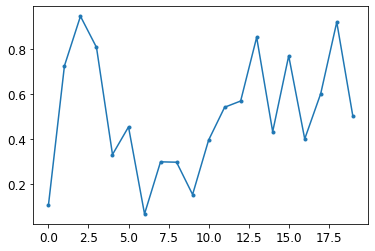

In [48]:
plt.plot(x, y, '.-');

-------

In [49]:
def lanczos_kernal(x, a):
    if x>-a and x<a:
        return np.sinc(x) * np.sinc(x/a)
    else:
        return 0

def lanczoc_interp(x, s, a):
    ss = 0.
    for ii in range(int(np.floor(x))-a+1, int(np.floor(x))+a+1):
        if ii>=0 and ii<=len(s)-1:
            ss += s[ii] * lanczos_kernal(x-ii, a)
    return ss

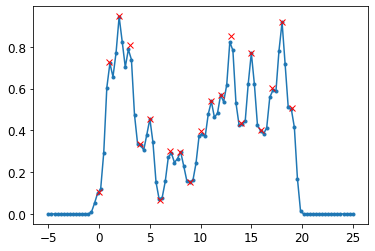

In [58]:
xx = np.linspace(-5, 25, 100)
yy = np.zeros(len(xx))
for index in range(len(yy)):
    yy[index] = lanczoc_interp(xx[index], y, 1)
    
plt.plot(xx, yy, '.-')
plt.plot(x, y, 'rx')
plt.show()

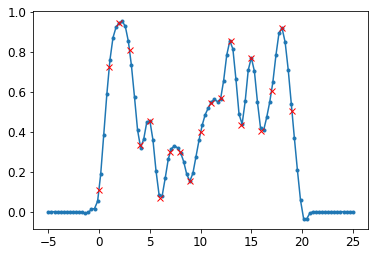

In [59]:
xx = np.linspace(-5, 25, 100)
yy = np.zeros(len(xx))
for index in range(len(yy)):
    yy[index] = lanczoc_interp(xx[index], y, 2)
    
plt.plot(xx, yy, '.-')
plt.plot(x, y, 'rx')
plt.show()

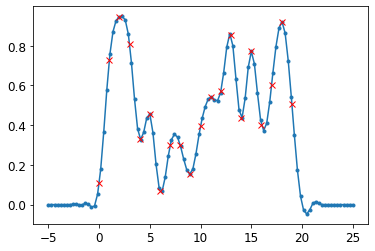

In [60]:
xx = np.linspace(-5, 25, 100)
yy = np.zeros(len(xx))
for index in range(len(yy)):
    yy[index] = lanczoc_interp(xx[index], y, 3)
    
plt.plot(xx, yy, '.-')
plt.plot(x, y, 'rx')
plt.show()

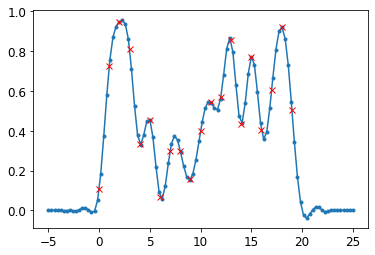

In [62]:
xx = np.linspace(-5, 25, 100)
yy = np.zeros(len(xx))
for index in range(len(yy)):
    yy[index] = lanczoc_interp(xx[index], y, 4)
    
plt.plot(xx, yy, '.-')
plt.plot(x, y, 'rx')
plt.show()

--------
# Compare with cv2

In [91]:
import cv2

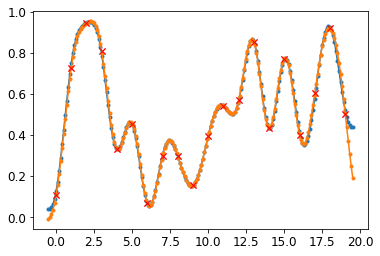

In [92]:
xx = np.linspace(-0.5, 19.5, 10*len(y))
ycv = cv2.resize(np.array([y]), (10*len(y), 1), interpolation=cv2.INTER_LANCZOS4)[0]
plt.plot(x, y, 'rx');
plt.plot(xx, ycv, '.-');

yy = np.zeros(len(xx))
for index in range(len(yy)):
    yy[index] = lanczoc_interp(xx[index], y, 4)
plt.plot(xx, yy, '.-')
plt.plot(x, y, 'rx')
plt.show()